# EduPath AI - Data Understanding, EDA, dan Dataset Preparation

Notebook ini digunakan untuk memahami dataset OULAD, melakukan eksplorasi data, membuat fitur utama EduPath AI, serta menghasilkan dataset `edupath_dataset_v1.csv` yang siap digunakan untuk tahap pemodelan Machine Learning.

In [5]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Persiapan Dataset

Pada tahap ini seluruh file CSV dari dataset OULAD dibaca menggunakan Pandas. Dataset OULAD terdiri dari beberapa tabel yang saling berhubungan, seperti data informasi siswa, assessment, aktivitas pembelajaran, dan data materi VLE.

In [11]:
assessments = pd.read_csv("../dataset/raw/assessments.csv")
courses = pd.read_csv("../dataset/raw/courses.csv")
studentAssessment = pd.read_csv("../dataset/raw/studentAssessment.csv")
studentInfo = pd.read_csv("../dataset/raw/studentInfo.csv")
studentRegistration = pd.read_csv("../dataset/raw/studentRegistration.csv")
studentVle = pd.read_csv("../dataset/raw/studentVle.csv")
vle = pd.read_csv("../dataset/raw/vle.csv")

# Exploratory Data Analysis (EDA)

EDA dilakukan untuk memahami struktur data, tipe data, distribusi nilai, missing value, serta pola awal yang berpotensi digunakan sebagai indikator dalam sistem EduPath AI.

### EDA Assessments Dataset

**Deskripsi Variabel:**

- code_module = Kode identifikasi dari suatu modul
- code_presentation = Kode identifikasi presentasi
- id_assessment = Nomor identifikasi penilaian
- assessment_type = Jenis penilaian. Penilaian yang ditandai tutor (TMA), penilaian yang ditandai komputer (CMA), ujian akhir (Exam)
- date = Tanggal pengumpulan akhir penilaian dalam satuan hari dihitung setelah presentasi modul
- weight = Bobot penilaian dalam persentase

In [12]:
# Menampilkan dataset
assessments.head()

,code_module,code_presentation,id_assessment,assessment_type,date,weight
0,AAA,2013J,1752,TMA,19.0,10.0
1,AAA,2013J,1753,TMA,54.0,20.0
2,AAA,2013J,1754,TMA,117.0,20.0
3,AAA,2013J,1755,TMA,166.0,20.0
4,AAA,2013J,1756,TMA,215.0,30.0


In [13]:
# Menampilkan informasi dari dataset
assessments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206 entries, 0 to 205
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   code_module        206 non-null    object 
 1   code_presentation  206 non-null    object 
 2   id_assessment      206 non-null    int64  
 3   assessment_type    206 non-null    object 
 4   date               195 non-null    float64
 5   weight             206 non-null    float64
dtypes: float64(2), int64(1), object(3)
memory usage: 9.8+ KB


In [22]:
# Menghapus missing values
assessments.dropna(inplace=True)

In [23]:
# Menampilkan statistik dari dataset
assessments.describe(include="all")

,code_module,code_presentation,id_assessment,assessment_type,date,weight
count,195,195,195.000000,195,195.000000,195.000000
unique,7,4,NaN,3,NaN,NaN
top,FFF,2014B,NaN,TMA,NaN,NaN
freq,52,54,NaN,106,NaN,NaN
mean,NaN,NaN,26851.056410,NaN,145.005128,16.410256
std,NaN,NaN,9830.992674,NaN,76.001119,24.505488
min,NaN,NaN,1752.000000,NaN,12.000000,0.000000
25%,NaN,NaN,24282.500000,NaN,71.000000,0.000000
50%,NaN,NaN,25367.000000,NaN,152.000000,10.000000
75%,NaN,NaN,34892.500000,NaN,222.000000,20.000000


In [16]:
# Menampilkan jumlah tiap kategori pada kolom code_module dan assessment_type
code_module = pd.DataFrame(assessments["code_module"].value_counts())
assessment_type = pd.DataFrame(assessments["assessment_type"].value_counts())

print(code_module)
print(assessment_type)

             count
code_module       
FFF             52
BBB             38
DDD             34
GGG             30
CCC             16
EEE             15
AAA             10
                 count
assessment_type       
TMA                106
CMA                 76
Exam                13


<Axes: xlabel='weight', ylabel='Count'>

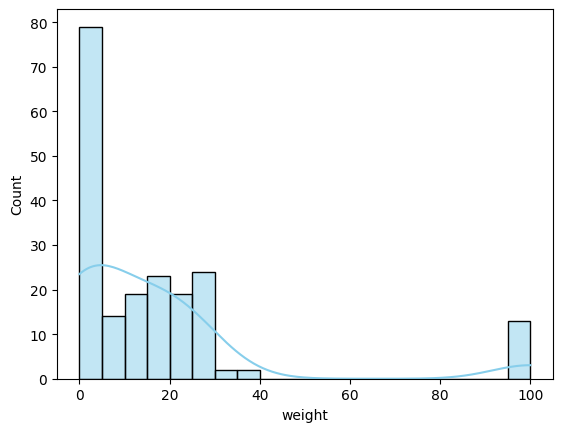

In [17]:
# Menampilkan distribusi dari kolom weight
sns.histplot(assessments["weight"], kde=True, bins=20, color="skyblue", edgecolor="black")

### EDA Courses Dataset

**Deskripsi Variabel**

- code_module = Kode identifikasi dari suatu modul
- code_presentation = Kode identifikasi presentasi. 4 angka depan menandakan tahun dan huruf terakhir bulan. (B: February; J: Oktober)
- module_presentation_length = Durasi presentasi modul dalam hari

In [18]:
# Menampilkan dataset
courses.head()

,code_module,code_presentation,module_presentation_length
0,AAA,2013J,268
1,AAA,2014J,269
2,BBB,2013J,268
3,BBB,2014J,262
4,BBB,2013B,240


In [19]:
# Menampilkan informasi dari dataset
courses.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 3 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   code_module                 22 non-null     object
 1   code_presentation           22 non-null     object
 2   module_presentation_length  22 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 660.0+ bytes


In [20]:
# Menampilkan statistik dari dataset
courses.describe(include="all")

,code_module,code_presentation,module_presentation_length
count,22,22,22.000000
unique,7,4,NaN
top,BBB,2014J,NaN
freq,4,7,NaN
mean,NaN,NaN,255.545455
std,NaN,NaN,13.654677
min,NaN,NaN,234.000000
25%,NaN,NaN,241.000000
50%,NaN,NaN,261.500000
75%,NaN,NaN,268.000000


<Axes: xlabel='module_presentation_length', ylabel='Count'>

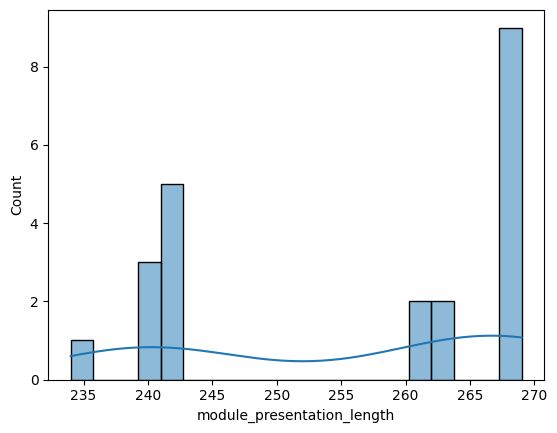

In [24]:
# Menampilkan distribusi dari kolom module_presentation_length
sns.histplot(courses["module_presentation_length"], kde=True, bins=20)

### EDA studentAssessment Dataset

**Deskripsi Variabel:**

- id_assessment: Nomor identifikasi assessment tersebut
- id_student: Nomor identifikasi unik untuk siswa
- date_submitted: Tanggal pengumpulan tugas siswa, dihitung sejak presentasi modul
- is_banked: Status penilaian
- score: Nilai siswa dalam assessment dengan rentang 0-100. Nilai dibawah 40 diartikan sebagai Gagal

In [25]:
# Menampilkan dataset
studentAssessment.head()

,id_assessment,id_student,date_submitted,is_banked,score
0,1752,11391,18,0,78.0
1,1752,28400,22,0,70.0
2,1752,31604,17,0,72.0
3,1752,32885,26,0,69.0
4,1752,38053,19,0,79.0


In [26]:
# Menampilkan informasi dari dataset
studentAssessment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 173912 entries, 0 to 173911
Data columns (total 5 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id_assessment   173912 non-null  int64  
 1   id_student      173912 non-null  int64  
 2   date_submitted  173912 non-null  int64  
 3   is_banked       173912 non-null  int64  
 4   score           173739 non-null  float64
dtypes: float64(1), int64(4)
memory usage: 6.6 MB


In [27]:
# Menghapus missing values
studentAssessment.dropna(inplace=True)

In [28]:
# Menampilkan statistik dari dataset
studentAssessment.describe(include="all")

,id_assessment,id_student,date_submitted,is_banked,score
count,173739.000000,1.737390e+05,173739.000000,173739.000000,173739.000000
mean,26555.615826,7.052474e+05,116.020226,0.010982,75.799573
std,8829.999907,5.524822e+05,71.479612,0.104218,18.798107
min,1752.000000,6.516000e+03,-11.000000,0.000000,0.000000
25%,15022.000000,5.044660e+05,51.000000,0.000000,65.000000
50%,25359.000000,5.852220e+05,116.000000,0.000000,80.000000
75%,34883.000000,6.345000e+05,173.000000,0.000000,90.000000
max,37443.000000,2.698588e+06,608.000000,1.000000,100.000000


In [29]:
# Mengidentifikasi seberapa banyak siswam yang dikatakan gagal (score < 40) dan berhasil (score >= 40)
num_success = 0
num_failed = 0

for score in studentAssessment["score"]:
    if score < 40:
        num_failed += 1
    else:
        num_success += 1
print(f"Jumlah siswa sukses: {num_success}")
print(f"Jumlah siswa gagal: {num_failed}")

Jumlah siswa sukses: 166161
Jumlah siswa gagal: 7578


In [30]:
# Melihat jumlah status penilaian
is_banked = pd.DataFrame(studentAssessment["is_banked"].value_counts())
is_banked

,count
is_banked,
0,171831
1,1908


<Axes: xlabel='date_submitted', ylabel='Count'>

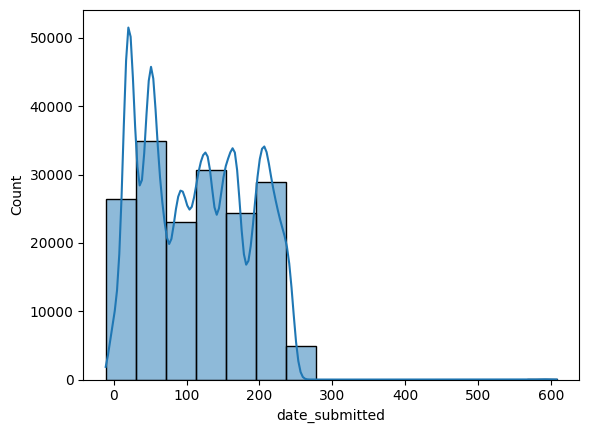

In [31]:
# Menampilkan distribusi tanggal pengumpulan siswa
sns.histplot(studentAssessment["date_submitted"], kde=True, bins=15)

### EDA studentInfo Dataset

**Deskripsi Variabel:**

- code_modul: Kode identifikasi unik untuk modul
- code_presentation: Kode identifikas presentasi
- id_student = Nomor identifikasi unik untuk siswa
- gender: Gender siswa
- region: Wilayah tempat siswa tinggal
- highest_eduacation: Tingkat pendidikan tertinggi siswa
- imd_band: Indeks kemiskinan multidimensi di tempat tinggal mahasiswa
- age_band: Kelompok usia siswa
- num_of_prev_attempts: Jumlah percobaan siswa terhadap modul tersebut
- studied_credits: Jumlah total kredit untuk modul yang sedang dipelajari siswa
- disability: Menyatakan apakah siswa disabilitas atau tidak
- final_result: Hasil akhir mahasiswa dalam presentasi modul

In [32]:
# Menampilkan dataset
studentInfo.head()

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass


In [33]:
# Menampilkan informasi dari dataset
studentInfo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   code_module           32593 non-null  object
 1   code_presentation     32593 non-null  object
 2   id_student            32593 non-null  int64 
 3   gender                32593 non-null  object
 4   region                32593 non-null  object
 5   highest_education     32593 non-null  object
 6   imd_band              31482 non-null  object
 7   age_band              32593 non-null  object
 8   num_of_prev_attempts  32593 non-null  int64 
 9   studied_credits       32593 non-null  int64 
 10  disability            32593 non-null  object
 11  final_result          32593 non-null  object
dtypes: int64(3), object(9)
memory usage: 3.0+ MB


In [34]:
# Menghapus missing values
studentInfo.dropna(inplace=True)

In [35]:
# Menampilkan statistik dari dataset
studentInfo.describe(include="all")

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
count,31482,31482,3.148200e+04,31482,31482,31482,31482,31482,31482.000000,31482.000000,31482,31482
unique,7,4,NaN,2,13,5,10,3,NaN,NaN,2,4
top,BBB,2014J,NaN,M,Scotland,A Level or Equivalent,20-30%,0-35,NaN,NaN,N,Pass
freq,7846,10865,NaN,17067,3434,13762,3654,22272,NaN,NaN,28351,11830
mean,NaN,NaN,7.069493e+05,NaN,NaN,NaN,NaN,NaN,0.164507,79.767804,NaN,NaN
std,NaN,NaN,5.505441e+05,NaN,NaN,NaN,NaN,NaN,0.482633,41.049455,NaN,NaN
min,NaN,NaN,3.733000e+03,NaN,NaN,NaN,NaN,NaN,0.000000,30.000000,NaN,NaN
25%,NaN,NaN,5.076005e+05,NaN,NaN,NaN,NaN,NaN,0.000000,60.000000,NaN,NaN
50%,NaN,NaN,5.898190e+05,NaN,NaN,NaN,NaN,NaN,0.000000,60.000000,NaN,NaN
75%,NaN,NaN,6.441622e+05,NaN,NaN,NaN,NaN,NaN,0.000000,120.000000,NaN,NaN


In [36]:
# Menampilkan jumlah value untuk tiap kategori pada kolom gender
studentInfo_gender = pd.DataFrame(studentInfo["gender"].value_counts())
studentInfo_final_result = pd.DataFrame(studentInfo["final_result"].value_counts())
studentInfo_final_result

,count
final_result,
Pass,11830
Withdrawn,9920
Fail,6907
Distinction,2825


<BarContainer object of 13 artists>

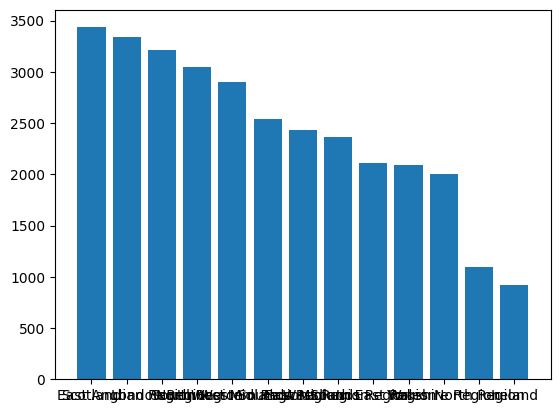

In [37]:
studentInfo_region = pd.DataFrame(studentInfo["region"].value_counts()).reset_index()
plt.bar(studentInfo_region["region"], studentInfo_region["count"])

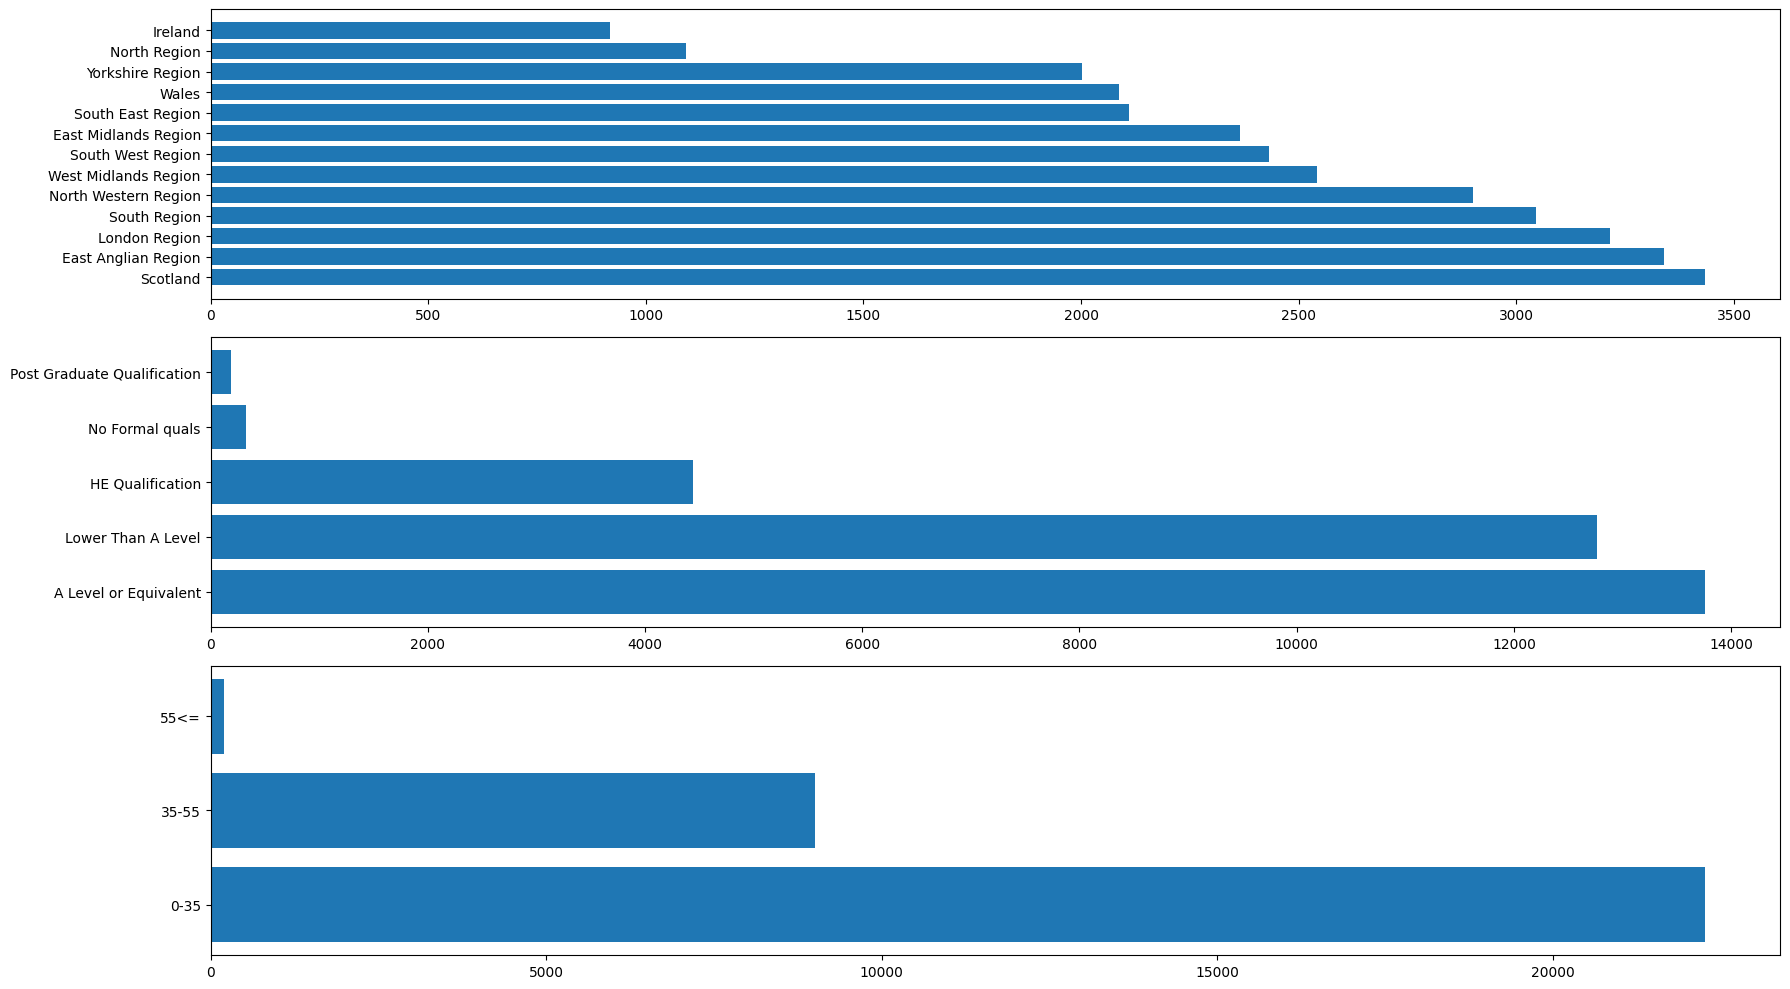

In [38]:
# Menampilkan visualisasi dari kolom region, highest_education, age_band
studentInfo_region = pd.DataFrame(studentInfo["region"].value_counts()).reset_index()
studentInfo_highest_education = pd.DataFrame(studentInfo["highest_education"].value_counts()).reset_index()
studentInfo_age_band = pd.DataFrame(studentInfo["age_band"].value_counts()).reset_index()

dataframe_column = [studentInfo_region["region"], studentInfo_highest_education["highest_education"], studentInfo_age_band["age_band"]]
dataframe_value = [studentInfo_region["count"], studentInfo_highest_education["count"], studentInfo_age_band["count"]]

fig, ax = plt.subplots(3, 1, figsize=(18, 10))
ax = ax.flatten()

for i in range(3):
    ax[i].barh(dataframe_column[i], dataframe_value[i])

plt.tight_layout()
plt.show()

### EDA studentRegistration Dataset

**Deskripsi Variabel:**

- code_module: Kode identifikasi untuk sebuah modul
- code_presentation: Kode identifikasi presentasi
- id_student: Nomor identifikasi unik untuk siswa
- date_registration: Tanggal pendaftaran siswa diukur sebagai jumlah hari sebelum presentasi modul dimulai
- date_unregistration: Tanggal ketidakdaftaran siswa sejak presentasi modul. siswa yang membatalkan pendaftaran akan memiliki value "Withdrawal" pada kolom final_result

In [39]:
# Menampilkan dataset
studentRegistration.head()

,code_module,code_presentation,id_student,date_registration,date_unregistration
0,AAA,2013J,11391,-159.0,NaN
1,AAA,2013J,28400,-53.0,NaN
2,AAA,2013J,30268,-92.0,12.0
3,AAA,2013J,31604,-52.0,NaN
4,AAA,2013J,32885,-176.0,NaN


In [40]:
# Menampilkan informasi dari dataset
studentRegistration.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   code_module          32593 non-null  object 
 1   code_presentation    32593 non-null  object 
 2   id_student           32593 non-null  int64  
 3   date_registration    32548 non-null  float64
 4   date_unregistration  10072 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 1.2+ MB


In [41]:
# Menghapus kolom yang ada missing values dan baris yang ada missing values
studentRegistration.drop(columns="date_unregistration", inplace=True)
studentRegistration.dropna(axis=0, inplace=True)

In [42]:
studentRegistration.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32548 entries, 0 to 32592
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   code_module        32548 non-null  object 
 1   code_presentation  32548 non-null  object 
 2   id_student         32548 non-null  int64  
 3   date_registration  32548 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 1.2+ MB


In [43]:
# Menampilkan statistik dari datset
studentRegistration.describe(include="all")

,code_module,code_presentation,id_student,date_registration
count,32548,32548,3.254800e+04,32548.000000
unique,7,4,NaN,NaN
top,BBB,2014J,NaN,NaN
freq,7900,11251,NaN,NaN
mean,NaN,NaN,7.061734e+05,-69.411300
std,NaN,NaN,5.483864e+05,49.260522
min,NaN,NaN,3.733000e+03,-322.000000
25%,NaN,NaN,5.085320e+05,-100.000000
50%,NaN,NaN,5.902380e+05,-57.000000
75%,NaN,NaN,6.443902e+05,-29.000000


<Axes: xlabel='date_registration', ylabel='Count'>

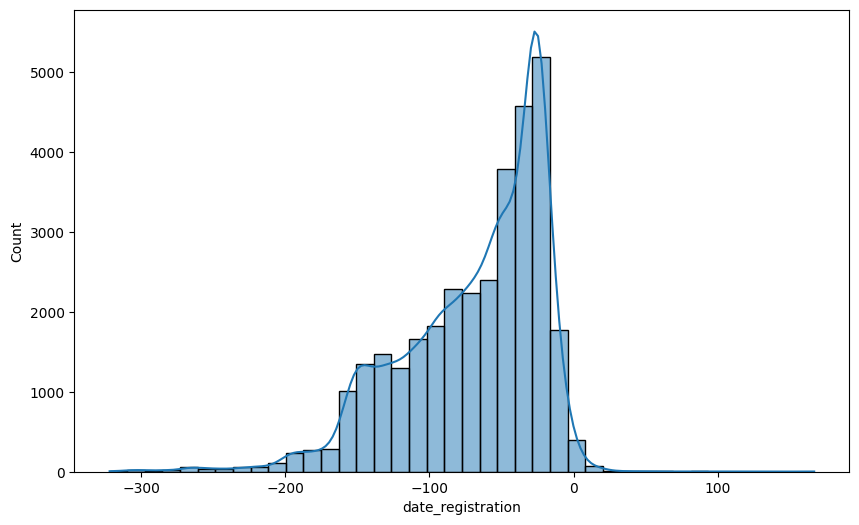

In [44]:
# Menampilkan distribusi dari kolom date_registration
plt.figure(figsize=(10, 6))
sns.histplot(studentRegistration["date_registration"], kde=True, bins=40)

### EDA studentVle Dataset

**Deskripsi Variabel:**

- code_module = Kode identifikasi unik untuk sebuah modul
- code_presentation = Kode identifikasi presentasi
- id_student = Nomor identifikasi unik untuk siswa
- id_site = Nomor identfikasi untuk materi VLE
- date = Tanggal interaksi siswa dengan modul diukur sebagai jumlah haru setelah presentasi modul
- sum_click = Seberapa banyak siswa berinteraksi (klik) dengan materi tersebut pada hari itu

In [45]:
# Menampilkan dataset
studentVle.head()

,code_module,code_presentation,id_student,id_site,date,sum_click
0,AAA,2013J,28400,546652,-10,4
1,AAA,2013J,28400,546652,-10,1
2,AAA,2013J,28400,546652,-10,1
3,AAA,2013J,28400,546614,-10,11
4,AAA,2013J,28400,546714,-10,1


In [46]:
# Menampilkan informasi dari dataset
studentVle.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10655280 entries, 0 to 10655279
Data columns (total 6 columns):
 #   Column             Dtype 
---  ------             ----- 
 0   code_module        object
 1   code_presentation  object
 2   id_student         int64 
 3   id_site            int64 
 4   date               int64 
 5   sum_click          int64 
dtypes: int64(4), object(2)
memory usage: 487.8+ MB


In [47]:
# Menampilkan statistik dari dataset
studentVle.describe(include="all")

,code_module,code_presentation,id_student,id_site,date,sum_click
count,10655280,10655280,1.065528e+07,1.065528e+07,1.065528e+07,1.065528e+07
unique,7,4,NaN,NaN,NaN,NaN
top,FFF,2014J,NaN,NaN,NaN,NaN
freq,4014499,3619452,NaN,NaN,NaN,NaN
mean,NaN,NaN,7.333336e+05,7.383234e+05,9.517400e+01,3.716946e+00
std,NaN,NaN,5.827060e+05,1.312196e+05,7.607130e+01,8.849047e+00
min,NaN,NaN,6.516000e+03,5.267210e+05,-2.500000e+01,1.000000e+00
25%,NaN,NaN,5.077430e+05,6.735190e+05,2.500000e+01,1.000000e+00
50%,NaN,NaN,5.882360e+05,7.300690e+05,8.600000e+01,2.000000e+00
75%,NaN,NaN,6.464840e+05,8.770300e+05,1.560000e+02,3.000000e+00


### EDA Vle Dataset

**Deskripsi Variabel:**

- id_site = Nomor identifikasi untuk materi
- code_module = Kode identifikasi unik untuk sebuah modul
- code_presentation = Kode identifikasi presentasi
- activity_type = Peran yang terkait dengan materi modul
- week_from = Minggu di mana materi tersebut direncakan untuk digunakan
- week_to = Minggu hingga materi tersebut direncanakan untuk digunakan

In [48]:
# Menampilkan Dataset
vle.head()

,id_site,code_module,code_presentation,activity_type,week_from,week_to
0,546943,AAA,2013J,resource,NaN,NaN
1,546712,AAA,2013J,oucontent,NaN,NaN
2,546998,AAA,2013J,resource,NaN,NaN
3,546888,AAA,2013J,url,NaN,NaN
4,547035,AAA,2013J,resource,NaN,NaN


In [49]:
# Menampilkan informasi dari dataset
vle.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6364 entries, 0 to 6363
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_site            6364 non-null   int64  
 1   code_module        6364 non-null   object 
 2   code_presentation  6364 non-null   object 
 3   activity_type      6364 non-null   object 
 4   week_from          1121 non-null   float64
 5   week_to            1121 non-null   float64
dtypes: float64(2), int64(1), object(3)
memory usage: 298.4+ KB


In [50]:
# Mengatasi missing value dengan imputasi, kolom week_from diisi 0 dan kolom week_to diisi 30
vle["week_from"] = vle["week_from"].fillna(0)
vle["week_to"] = vle["week_to"].fillna(30)

In [51]:
# Menampilkan statistik dari dataset
vle.describe(include="all")

,id_site,code_module,code_presentation,activity_type,week_from,week_to
count,6.364000e+03,6364,6364,6364,6364.000000,6364.000000
unique,NaN,7,4,20,NaN,NaN
top,NaN,FFF,2013J,resource,NaN,NaN
freq,NaN,1967,1772,2660,NaN,NaN
mean,7.260991e+05,NaN,NaN,NaN,2.678190,27.395663
std,1.283151e+05,NaN,NaN,NaN,6.867404,6.730222
min,5.267210e+05,NaN,NaN,NaN,0.000000,0.000000
25%,6.615928e+05,NaN,NaN,NaN,0.000000,30.000000
50%,7.300965e+05,NaN,NaN,NaN,0.000000,30.000000
75%,8.140162e+05,NaN,NaN,NaN,0.000000,30.000000


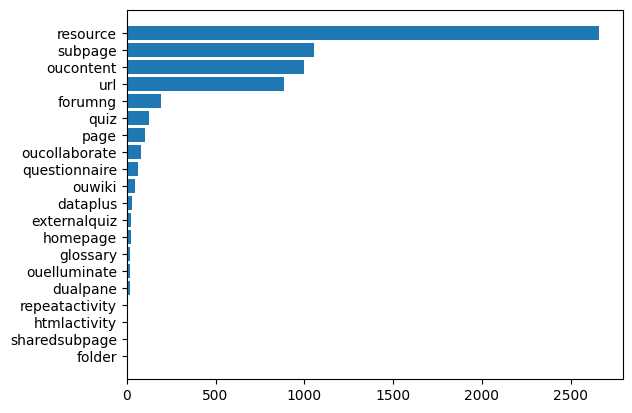

In [53]:
# Menampilkan
vle_activity_type = pd.DataFrame(vle["activity_type"].value_counts()).reset_index()

plt.barh(vle_activity_type["activity_type"], vle_activity_type["count"])
plt.gca().invert_yaxis()
plt.show()

### Insight Aktivitas VLE

Grafik di atas menunjukkan jenis aktivitas pembelajaran yang tersedia pada Virtual Learning Environment (VLE). Informasi ini penting karena aktivitas siswa pada platform pembelajaran dapat digunakan sebagai indikator keterlibatan belajar.

Dalam konteks EduPath AI, aktivitas belajar siswa akan diringkas menjadi fitur `total_click`, yaitu jumlah total interaksi belajar siswa selama menggunakan platform pembelajaran.

# Feature Engineering

Feature Engineering adalah proses membuat fitur baru dari data mentah agar lebih relevan untuk kebutuhan Machine Learning.

Pada proyek EduPath AI, kita membutuhkan fitur yang dapat menggambarkan:

1. **Performa akademik siswa**
2. **Aktivitas belajar siswa**
3. **Hasil akhir pembelajaran siswa**

Oleh karena itu, pada tahap ini dibuat dua fitur utama:

- `avg_score`: rata-rata nilai assessment setiap siswa.
- `total_click`: jumlah seluruh aktivitas klik siswa pada platform pembelajaran.

## Pembuatan Fitur Rata-Rata Nilai Siswa (`avg_score`)

Data pada tabel `studentAssessment` masih berbentuk data mentah, yaitu satu siswa dapat memiliki beberapa nilai assessment.

Agar data lebih mudah digunakan untuk Machine Learning, nilai assessment setiap siswa diringkas menjadi satu nilai rata-rata.

Fitur `avg_score` digunakan untuk merepresentasikan performa akademik siswa selama proses pembelajaran.

In [ ]:
avg_score = (
    studentAssessment
    .groupby("id_student")["score"]
    .mean()
    .reset_index()
)

avg_score.rename(
    columns={"score": "avg_score"},
    inplace=True
)

avg_score.head()

## Pembuatan Fitur Aktivitas Belajar (`total_click`)

Data pada tabel `studentVle` mencatat aktivitas klik siswa pada platform pembelajaran.

Untuk mengetahui tingkat keterlibatan belajar siswa, seluruh aktivitas klik dijumlahkan berdasarkan `id_student`.

Fitur `total_click` digunakan untuk merepresentasikan tingkat aktivitas belajar siswa.

In [ ]:
total_click = (
    studentVle
    .groupby("id_student")["sum_click"]
    .sum()
    .reset_index()
)

total_click.rename(
    columns={"sum_click": "total_click"},
    inplace=True
)

total_click.head()

# Dataset Preparation

Setelah fitur `avg_score` dan `total_click` dibuat, langkah berikutnya adalah menggabungkan data utama siswa dengan fitur hasil Feature Engineering.

Dataset hasil penggabungan ini disebut **EduPath Dataset v1**.

Dataset ini akan menjadi dasar untuk proses pemodelan Machine Learning pada tahap berikutnya.

## Pemilihan Data Utama Siswa

Pada tahap ini dipilih beberapa kolom penting dari tabel `studentInfo`.

Kolom yang dipilih meliputi identitas siswa, profil dasar siswa, riwayat percobaan, jumlah kredit yang dipelajari, dan hasil akhir pembelajaran.

Kolom `id_student` digunakan sebagai penghubung antar tabel.

In [ ]:
student_master = studentInfo[
    [
        "id_student",
        "gender",
        "highest_education",
        "age_band",
        "num_of_prev_attempts",
        "studied_credits",
        "final_result"
    ]
]

student_master.head()

## Penggabungan Data

Pada tahap ini dilakukan proses penggabungan dataset menggunakan kolom `id_student`.

Data yang digabungkan:

1. `student_master`: data utama siswa.
2. `avg_score`: rata-rata nilai assessment siswa.
3. `total_click`: total aktivitas belajar siswa.

Hasil penggabungan disimpan ke dalam variabel `edupath_df`.

In [ ]:
edupath_df = student_master.merge(
    avg_score,
    on="id_student",
    how="inner"
)

edupath_df = edupath_df.merge(
    total_click,
    on="id_student",
    how="inner"
)

edupath_df.head()

## Ukuran Dataset EduPath v1

Setelah proses penggabungan selesai, dilakukan pengecekan ukuran dataset untuk mengetahui jumlah baris dan kolom pada dataset akhir.

In [ ]:
edupath_df.shape

# Target Creation

EduPath AI membutuhkan target klasifikasi untuk menentukan apakah siswa membutuhkan remedial atau tidak.

Dataset OULAD tidak menyediakan kolom `needs_remedial` secara langsung, sehingga target ini dibuat dari kolom `final_result`.

Aturan yang digunakan:

- `Fail` → `1` atau perlu remedial
- `Withdrawn` → `1` atau perlu remedial
- `Pass` → `0` atau tidak perlu remedial
- `Distinction` → `0` atau tidak perlu remedial

Target ini akan digunakan pada tahap pemodelan Machine Learning.

In [ ]:
edupath_df["needs_remedial"] = edupath_df["final_result"].apply(
    lambda x: 1 if x in ["Fail", "Withdrawn"] else 0
)

edupath_df.head()

## Distribusi Target `needs_remedial`

Distribusi target digunakan untuk mengetahui jumlah data pada setiap kelas.

Hal ini penting karena dataset yang terlalu tidak seimbang dapat mempengaruhi performa model Machine Learning.

In [ ]:
edupath_df["needs_remedial"].value_counts()

## Pemeriksaan Missing Value

Sebelum dataset digunakan untuk pemodelan, perlu dilakukan pemeriksaan missing value.

Missing value dapat mempengaruhi proses analisis dan pelatihan model, sehingga perlu ditangani terlebih dahulu.

In [ ]:
edupath_df.isnull().sum()

## Penanganan Missing Value

Baris yang masih memiliki missing value dihapus menggunakan `dropna()`.

Pada dataset ini jumlah missing value relatif kecil, sehingga penghapusan baris tidak berdampak besar terhadap keseluruhan data.

In [ ]:
edupath_df = edupath_df.dropna()

edupath_df.isnull().sum()

# Correlation Analysis

Analisis korelasi dilakukan untuk melihat hubungan antar fitur numerik.

Pada tahap ini, fitur numerik yang dianalisis adalah:

- `num_of_prev_attempts`
- `studied_credits`
- `avg_score`
- `total_click`
- `needs_remedial`

Analisis ini membantu memahami fitur mana yang memiliki hubungan dengan target `needs_remedial`.

In [ ]:
numeric_columns = [
    "num_of_prev_attempts",
    "studied_credits",
    "avg_score",
    "total_click",
    "needs_remedial"
]

correlation_matrix = edupath_df[numeric_columns].corr()
correlation_matrix

## Visualisasi Korelasi

Heatmap digunakan untuk mempermudah pembacaan hubungan antar fitur numerik.

Nilai korelasi mendekati 1 menunjukkan hubungan positif yang kuat, sedangkan nilai mendekati -1 menunjukkan hubungan negatif yang kuat.

In [ ]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix EduPath Dataset v1")
plt.show()

# Penyimpanan Dataset EduPath v1

Setelah proses Feature Engineering, penggabungan data, pembuatan target, dan pembersihan data selesai dilakukan, dataset disimpan dalam format CSV.

File `edupath_dataset_v1.csv` akan digunakan pada tahap berikutnya, yaitu pemodelan Machine Learning.

In [ ]:
os.makedirs("../dataset/processed", exist_ok=True)

edupath_df.to_csv(
    "../dataset/processed/edupath_dataset_v1.csv",
    index=False
)

print("Dataset EduPath v1 berhasil disimpan ke ../dataset/processed/edupath_dataset_v1.csv")

# Kesimpulan

Berdasarkan proses eksplorasi dan persiapan data yang telah dilakukan, berhasil dibangun dataset baru bernama **EduPath Dataset v1**.

Dataset ini merupakan hasil penggabungan data profil siswa, performa akademik, dan aktivitas belajar dari dataset OULAD.

Fitur utama yang berhasil dibuat adalah:

- `avg_score`: rata-rata nilai assessment siswa.
- `total_click`: total aktivitas belajar siswa.
- `needs_remedial`: target klasifikasi untuk menentukan kebutuhan remedial.

Dataset EduPath v1 ini sudah siap digunakan untuk tahap berikutnya, yaitu proses pemodelan Machine Learning.

Pada pengembangan berikutnya, EduPath AI perlu menambahkan fitur yang lebih spesifik seperti `topic_accuracy`, `attempt_count`, dan `study_duration` agar sistem dapat mengetahui tingkat pemahaman siswa pada setiap topik pembelajaran secara lebih detail.